# Hyperparameter Optimisation, Predictor Selection, and Final Model Evaluation

This notebook implements the following workflow:

1. optimise all eight classifiers using the full set of 32 candidate
   predictors;
2. retrieve the exact tuned Logistic Regression pipeline selected during
   hyperparameter optimisation;
3. apply the same pipeline specification to permutation-based predictor
   ranking and ranked predictor-subset evaluation;
4. retain and report the selected predictors and generate the
   publication-ready predictor-importance plot; and
5. refit the selected-predictor pipeline on the complete training set and
   evaluate it once on the untouched held-out test set.

## 1. Imports and reproducibility settings

In [1]:
from pathlib import Path
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import imblearn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

# Reproducibility
MODEL_SEED = 0
CV_SEED = 0
SPLIT_SEED = 20
SMOTE_SEED = 20
SELECTION_SEED = 0

# Data split
TEST_SIZE = 0.20

# Hyperparameter optimisation
N_SPLITS = 5
N_REPEATS = 5
SCORING = "f1_macro"

# Fixed Logistic Regression convergence setting; this is not tuned.
LR_MAX_ITER = 5000

# Predictor-subset evaluation
OUTER_SPLITS = 5
OUTER_REPEATS = 5
INNER_SPLITS = 5
INNER_PERMUTATION_REPEATS = 5

# Final cross-validated ranking
FINAL_RANKING_SPLITS = 5
FINAL_RANKING_REPEATS = 5
FINAL_PERMUTATION_REPEATS = 10

OUTPUT_DIR = Path("combined_phase2_phase3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    Path("DATA.xlsx"),
    Path("D:/Project/DATA.xlsx"),
]

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print(
    "Repeated-CV scores per hyperparameter setting:",
    N_SPLITS * N_REPEATS,
)
print(
    "Outer validation scores per predictor count:",
    OUTER_SPLITS * OUTER_REPEATS,
)

Python: 3.13.14
scikit-learn: 1.8.0
imbalanced-learn: 0.14.1
Repeated-CV scores per hyperparameter setting: 25
Outer validation scores per predictor count: 25


## 2. Load the dataset and construct the binary outcome

In [2]:
data_path = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None,
)

if data_path is None:
    raise FileNotFoundError(
        "The 408-respondent Excel file was not found. Place "
        "'TikTok_Purchase_Behaviour_408_Respondents.xlsx' or "
        "'DATA.xlsx' beside this notebook, or update DATA_CANDIDATES."
    )

df = pd.read_excel(data_path).copy()

PB_ITEMS = ["PB1", "PB2", "PB3", "PB4"]

missing_pb_items = [
    column for column in PB_ITEMS
    if column not in df.columns
]

if missing_pb_items:
    raise KeyError(
        f"Missing purchase-behaviour items: {missing_pb_items}"
    )

df["PB_sum"] = df[PB_ITEMS].sum(axis=1)

# LOW = 4–12; HIGH = 13–20
df["PB_inf"] = np.where(
    df["PB_sum"] <= 12,
    "LOW",
    "HIGH",
)

class_distribution = (
    df["PB_inf"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / class_distribution["Count"].sum()
    * 100
)

print("Loaded:", data_path)
print("Original shape:", df.shape)
display(class_distribution.round(2))

Loaded: DATA.xlsx
Original shape: (408, 48)


,Class,Count,Percentage
0,HIGH,298,73.04
1,LOW,110,26.96


## 3. Define the 32 candidate predictors

In [3]:
ATTD_COLUMNS = [
    "ATTD1", "ATTD2", "ATTD3", "ATTD4"
]

PBC_COLUMNS = [
    "PBC1", "PBC2", "PBC3", "PBC4"
]

SN_COLUMNS = [
    "SN1", "SN2", "SN3", "SN4"
]

VIDEO_COLUMNS = [
    "V1", "V2", "V3",
    "E1", "E2", "E3",
    "H1", "H2",
    "A1", "A2", "A3",
    "T1", "T2", "T3",
    "P1", "P2", "P3",
    "EM1", "EM2", "EM3",
]

TPB_COLUMNS = (
    ATTD_COLUMNS
    + PBC_COLUMNS
    + SN_COLUMNS
)

ALL_PREDICTORS = (
    TPB_COLUMNS
    + VIDEO_COLUMNS
)

missing_predictors = [
    column for column in ALL_PREDICTORS
    if column not in df.columns
]

if missing_predictors:
    raise KeyError(
        f"Missing required predictors: {missing_predictors}"
    )

analysis_df = (
    df[ALL_PREDICTORS + ["PB_inf"]]
    .dropna()
    .reset_index(drop=True)
)

X = analysis_df[ALL_PREDICTORS].copy()
y = analysis_df["PB_inf"].copy()

assert len(TPB_COLUMNS) == 12
assert len(VIDEO_COLUMNS) == 20
assert len(ALL_PREDICTORS) == 32

print("Analysis sample size:", len(analysis_df))
print("TPB predictors:", len(TPB_COLUMNS))
print("Video-content predictors:", len(VIDEO_COLUMNS))
print("Total candidate predictors:", len(ALL_PREDICTORS))

Analysis sample size: 408
TPB predictors: 12
Video-content predictors: 20
Total candidate predictors: 32


## 4. Reserve the untouched stratified test set

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SPLIT_SEED,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Subset": [
        "Full sample",
        "Training set",
        "Held-out test set",
    ],
    "N": [
        len(y),
        len(y_train),
        len(y_test),
    ],
    "LOW": [
        int((y == "LOW").sum()),
        int((y_train == "LOW").sum()),
        int((y_test == "LOW").sum()),
    ],
    "HIGH": [
        int((y == "HIGH").sum()),
        int((y_train == "HIGH").sum()),
        int((y_test == "HIGH").sum()),
    ],
})

display(split_summary)

print("Training shape:", X_train.shape)
print("Held-out test shape:", X_test.shape)

,Subset,N,LOW,HIGH
0,Full sample,408,110,298
1,Training set,326,88,238
2,Held-out test set,82,22,60


Training shape: (326, 32)
Held-out test shape: (82, 32)


## 5. Define leakage-safe pipelines and hyperparameter grids

In [5]:
def make_repeated_cv():
    return RepeatedStratifiedKFold(
        n_splits=N_SPLITS,
        n_repeats=N_REPEATS,
        random_state=CV_SEED,
    )


classifiers = {
    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=MODEL_SEED,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=MODEL_SEED,
        n_jobs=1,
    ),

    "Logistic Regression": LogisticRegression(
        random_state=MODEL_SEED,
        max_iter=LR_MAX_ITER,
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(),

    "AdaBoost": AdaBoostClassifier(
        random_state=MODEL_SEED,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=MODEL_SEED,
    ),
}

NB_VAR_SMOOTHING_GRID = np.logspace(-12, -6, 13)

param_grids = {
    "KNN": {
        "model__n_neighbors": np.arange(1, 11),
    },

    "Decision Tree": {
        "model__max_depth": np.arange(1, 11),
        "model__criterion": ["gini", "entropy"],
    },

    "Random Forest": {
        "model__n_estimators": [10, 50, 100, 200],
        "model__max_depth": np.arange(1, 11),
        "model__criterion": ["gini", "entropy"],
    },

    "Logistic Regression": {
        "model__C": np.logspace(-4, 4, 9),
        "model__solver": [
            "newton-cg",
            "lbfgs",
            "liblinear",
            "sag",
            "saga",
        ],
    },

    "Naive Bayes": {
        "model__var_smoothing": NB_VAR_SMOOTHING_GRID,
    },

    "SVM": {
        "model__C": np.logspace(-3, 3, 7),
        "model__kernel": [
            "linear",
            "poly",
            "rbf",
            "sigmoid",
        ],
        "model__gamma": [
            "scale",
            "auto",
        ],
    },

    "AdaBoost": {
        "model__n_estimators": [10, 50, 100, 200],
        "model__learning_rate": [0.001, 0.01, 0.1, 1],
    },

    "Gradient Boosting": {
        "model__n_estimators": [10, 50, 100, 200],
        "model__learning_rate": [0.001, 0.01, 0.1, 1],
        "model__max_depth": np.arange(1, 11),
    },
}

SCALED_MODELS = {
    "KNN",
    "Logistic Regression",
    "SVM",
}


def make_leakage_safe_pipeline(
    model_name,
    estimator,
):
    scaler = (
        StandardScaler()
        if model_name in SCALED_MODELS
        else "passthrough"
    )

    return ImbPipeline(
        steps=[
            ("scaler", scaler),
            (
                "smote",
                SMOTE(random_state=SMOTE_SEED),
            ),
            ("model", clone(estimator)),
        ]
    )


parameter_grid_summary = pd.DataFrame({
    "Model": list(param_grids.keys()),
    "Number_of_Candidate_Settings": [
        len(list(ParameterGrid(grid)))
        for grid in param_grids.values()
    ],
})

display(parameter_grid_summary)

,Model,Number_of_Candidate_Settings
0,KNN,10
1,Decision Tree,20
2,Random Forest,80
3,Logistic Regression,45
4,Naive Bayes,13
5,SVM,56
6,AdaBoost,16
7,Gradient Boosting,160


## 6. Hyperparameter optimisation of all eight classifiers

In [6]:
grid_searches = {}
hyperparameter_rows = []

for model_name, estimator in classifiers.items():
    print(f"Optimising: {model_name}")

    search = GridSearchCV(
        estimator=make_leakage_safe_pipeline(
            model_name=model_name,
            estimator=estimator,
        ),
        param_grid=param_grids[model_name],
        scoring=SCORING,
        cv=make_repeated_cv(),
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        error_score="raise",
    )

    search.fit(
        X_train[ALL_PREDICTORS],
        y_train,
    )

    grid_searches[model_name] = search
    best_index = search.best_index_

    clean_parameters = {
        key.replace("model__", ""): value
        for key, value in search.best_params_.items()
    }

    hyperparameter_rows.append({
        "Model": model_name,
        "Best_Parameters": clean_parameters,
        "CV_Macro_F1_Mean": search.best_score_,
        "CV_Macro_F1_SD": (
            search.cv_results_["std_test_score"][best_index]
        ),
        "CV_Train_Macro_F1_Mean": (
            search.cv_results_["mean_train_score"][best_index]
        ),
        "Train_Validation_Gap": (
            search.cv_results_["mean_train_score"][best_index]
            - search.best_score_
        ),
        "Number_of_Candidate_Settings": (
            len(search.cv_results_["params"])
        ),
        "Number_of_Validation_Scores": N_SPLITS * N_REPEATS,
    })

hyperparameter_results = (
    pd.DataFrame(hyperparameter_rows)
    .sort_values(
        ["CV_Macro_F1_Mean", "CV_Macro_F1_SD"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(hyperparameter_results.round(4))

Optimising: KNN
Optimising: Decision Tree
Optimising: Random Forest
Optimising: Logistic Regression
Optimising: Naive Bayes
Optimising: SVM
Optimising: AdaBoost
Optimising: Gradient Boosting


,Model,Best_Parameters,CV_Macro_F1_Mean,CV_Macro_F1_SD,CV_Train_Macro_F1_Mean,Train_Validation_Gap,Number_of_Candidate_Settings,Number_of_Validation_Scores
0,Logistic Regression,"{'C': 0.01, 'solver': 'liblinear'}",0.8563,0.0346,0.8705,0.0141,45,25
1,Naive Bayes,{'var_smoothing': 1e-12},0.8511,0.0362,0.8499,-0.0012,13,25
2,Random Forest,"{'criterion': 'entropy', 'max_depth': 6, 'n_es...",0.8502,0.0390,0.9730,0.1228,80,25
3,SVM,"{'C': 1.0, 'gamma': 'auto', 'kernel': 'rbf'}",0.8454,0.0295,0.9408,0.0955,56,25
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.8420,0.0355,0.9646,0.1227,160,25
5,AdaBoost,"{'learning_rate': 0.1, 'n_estimators': 200}",0.8355,0.0380,0.8742,0.0387,16,25
6,KNN,{'n_neighbors': 8},0.8270,0.0341,0.8589,0.0319,10,25
7,Decision Tree,"{'criterion': 'gini', 'max_depth': 5}",0.7925,0.0399,0.9455,0.1530,20,25


In [7]:
from pathlib import Path

# Prepare the publication-ready Excel output.
hyperparameter_excel = hyperparameter_results.copy()

# Convert the parameter dictionaries into readable text.
hyperparameter_excel["Best_Parameters"] = (
    hyperparameter_excel["Best_Parameters"]
    .apply(
        lambda parameters: "; ".join(
            f"{parameter}={value}"
            for parameter, value in parameters.items()
        )
    )
)

# Round numerical results to four decimal places.
numeric_columns = [
    "CV_Macro_F1_Mean",
    "CV_Macro_F1_SD",
    "CV_Train_Macro_F1_Mean",
    "Train_Validation_Gap",
]

hyperparameter_excel[numeric_columns] = (
    hyperparameter_excel[numeric_columns].round(4)
)

# Save the complete results to Excel.
OUTPUT_FILE = Path(
    "Hyperparameter_Optimisation_Results.xlsx"
)

hyperparameter_excel.to_excel(
    OUTPUT_FILE,
    sheet_name="Hyperparameter Results",
    index=False,
)

print(f"Excel file saved to: {OUTPUT_FILE.resolve()}")

Excel file saved to: C:\Users\Acer\Dropbox\งาน Project\DM65\ML\Hyperparameter_Optimisation_Results.xlsx


## 7. Retrieve the exact tuned Logistic Regression pipeline

In [8]:
best_model_name = hyperparameter_results.iloc[0]["Model"]

if best_model_name != "Logistic Regression":
    raise RuntimeError(
        "The current run did not select Logistic Regression as the "
        f"highest-mean model; it selected {best_model_name!r}. "
        "Do not continue with the manuscript's LR claim until the "
        "data, split, seeds, and software versions are reconciled."
    )

lr_search = grid_searches["Logistic Regression"]

# This is the only Logistic Regression specification used below.
# No new LR model is manually identified or redefined in Phase 3.
tuned_lr_pipeline = clone(
    lr_search.best_estimator_
)

tuned_lr_model = (
    tuned_lr_pipeline.named_steps["model"]
)

tuned_lr_audit = pd.DataFrame([{
    "Source": (
        'grid_searches["Logistic Regression"].best_estimator_'
    ),
    "Tuned_C": tuned_lr_model.C,
    "Tuned_Solver": tuned_lr_model.solver,
    "Fixed_Max_Iter": tuned_lr_model.max_iter,
    "Fixed_Random_State": tuned_lr_model.random_state,
    "SMOTE_Random_State": (
        tuned_lr_pipeline.named_steps["smote"].random_state
    ),
    "Scaler": (
        tuned_lr_pipeline.named_steps["scaler"]
        .__class__.__name__
    ),
    "Repeated_CV_Macro_F1_Mean": lr_search.best_score_,
    "Repeated_CV_Macro_F1_SD": (
        lr_search.cv_results_["std_test_score"][
            lr_search.best_index_
        ]
    ),
}])

display(tuned_lr_audit.round(4))

# Consistency checks
assert np.isclose(
    tuned_lr_model.C,
    lr_search.best_params_["model__C"],
)
assert (
    tuned_lr_model.solver
    == lr_search.best_params_["model__solver"]
)
assert tuned_lr_model.max_iter == LR_MAX_ITER
assert tuned_lr_model.random_state == MODEL_SEED
assert (
    tuned_lr_pipeline.named_steps["smote"].random_state
    == SMOTE_SEED
)

print("Exact tuned LR parameters:", lr_search.best_params_)
print(
    "Fixed non-tuned max_iter:",
    tuned_lr_model.max_iter,
)

,Source,Tuned_C,Tuned_Solver,Fixed_Max_Iter,Fixed_Random_State,SMOTE_Random_State,Scaler,Repeated_CV_Macro_F1_Mean,Repeated_CV_Macro_F1_SD
0,"grid_searches[""Logistic Regression""].best_esti...",0.01,liblinear,5000,0,20,StandardScaler,0.8563,0.0346


Exact tuned LR parameters: {'model__C': np.float64(0.01), 'model__solver': 'liblinear'}
Fixed non-tuned max_iter: 5000


## 8. Cross-validated predictor-subset evaluation

The Logistic Regression hyperparameters are fixed from the preceding
hyperparameter-optimisation stage. For each outer fold, all 32
predictors are ranked using permutation importance calculated only from
inner validation folds. Candidate models containing the Top 1 through
Top 32 ranked predictors are then evaluated on the untouched outer
validation fold.

In [9]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=OUTER_SPLITS,
    n_repeats=OUTER_REPEATS,
    random_state=SELECTION_SEED,
)

FEATURE_K_VALUES = list(
    range(1, len(ALL_PREDICTORS) + 1)
)

feature_count_records = []
outer_ranking_records = []

number_of_outer_folds = (
    OUTER_SPLITS * OUTER_REPEATS
)

for outer_fold, (
    outer_train_index,
    outer_validation_index,
) in enumerate(
    outer_cv.split(X_train, y_train),
    start=1,
):
    print(
        f"Outer fold {outer_fold}/"
        f"{number_of_outer_folds}"
    )

    X_outer_train = X_train.iloc[
        outer_train_index
    ].copy()

    X_outer_validation = X_train.iloc[
        outer_validation_index
    ].copy()

    y_outer_train = y_train.iloc[
        outer_train_index
    ].copy()

    y_outer_validation = y_train.iloc[
        outer_validation_index
    ].copy()

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=SELECTION_SEED + outer_fold,
    )

    inner_importance_records = []

    for inner_fold, (
        inner_train_index,
        inner_validation_index,
    ) in enumerate(
        inner_cv.split(
            X_outer_train,
            y_outer_train,
        ),
        start=1,
    ):
        X_inner_train = X_outer_train.iloc[
            inner_train_index
        ]

        X_inner_validation = X_outer_train.iloc[
            inner_validation_index
        ]

        y_inner_train = y_outer_train.iloc[
            inner_train_index
        ]

        y_inner_validation = y_outer_train.iloc[
            inner_validation_index
        ]

        inner_pipeline = clone(
            tuned_lr_pipeline
        )

        inner_pipeline.fit(
            X_inner_train[ALL_PREDICTORS],
            y_inner_train,
        )

        inner_permutation = permutation_importance(
            estimator=inner_pipeline,
            X=X_inner_validation[ALL_PREDICTORS],
            y=y_inner_validation,
            scoring=SCORING,
            n_repeats=INNER_PERMUTATION_REPEATS,
            random_state=(
                SELECTION_SEED
                + outer_fold * 100
                + inner_fold
            ),
            n_jobs=-1,
        )

        for feature_index, feature_name in enumerate(
            ALL_PREDICTORS
        ):
            inner_importance_records.append({
                "Outer_Fold": outer_fold,
                "Inner_Fold": inner_fold,
                "Feature": feature_name,
                "Importance": (
                    inner_permutation.importances_mean[
                        feature_index
                    ]
                ),
            })

    inner_importance_df = pd.DataFrame(
        inner_importance_records
    )

    ranking_this_outer_fold = (
        inner_importance_df
        .groupby("Feature", as_index=False)
        .agg(
            Mean_Importance=("Importance", "mean"),
        )
        .sort_values(
            ["Mean_Importance", "Feature"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

    ranking_this_outer_fold["Outer_Fold"] = (
        outer_fold
    )
    ranking_this_outer_fold["Rank"] = np.arange(
        1,
        len(ranking_this_outer_fold) + 1,
    )

    outer_ranking_records.append(
        ranking_this_outer_fold
    )

    ranked_features = (
        ranking_this_outer_fold["Feature"]
        .tolist()
    )

    for k in FEATURE_K_VALUES:
        selected_features_fold = (
            ranked_features[:k]
        )

        candidate_pipeline = clone(
            tuned_lr_pipeline
        )

        candidate_pipeline.fit(
            X_outer_train[selected_features_fold],
            y_outer_train,
        )

        outer_prediction = candidate_pipeline.predict(
            X_outer_validation[selected_features_fold]
        )

        feature_count_records.append({
            "Outer_Fold": outer_fold,
            "Number_of_Selected_Predictors": k,
            "Number_of_TPB_Predictors": sum(
                feature in TPB_COLUMNS
                for feature in selected_features_fold
            ),
            "Number_of_Video_Predictors": sum(
                feature in VIDEO_COLUMNS
                for feature in selected_features_fold
            ),
            "Outer_Macro_F1": f1_score(
                y_outer_validation,
                outer_prediction,
                average="macro",
                zero_division=0,
            ),
        })

feature_count_results = pd.DataFrame(
    feature_count_records
)

outer_rankings = pd.concat(
    outer_ranking_records,
    ignore_index=True,
)

print(
    "Completed outer evaluations:",
    feature_count_results.shape[0],
)

Outer fold 1/25
Outer fold 2/25
Outer fold 3/25
Outer fold 4/25
Outer fold 5/25
Outer fold 6/25
Outer fold 7/25
Outer fold 8/25
Outer fold 9/25
Outer fold 10/25
Outer fold 11/25
Outer fold 12/25
Outer fold 13/25
Outer fold 14/25
Outer fold 15/25
Outer fold 16/25
Outer fold 17/25
Outer fold 18/25
Outer fold 19/25
Outer fold 20/25
Outer fold 21/25
Outer fold 22/25
Outer fold 23/25
Outer fold 24/25
Outer fold 25/25
Completed outer evaluations: 800


## 9. Select the predictor count with the highest mean outer-validation macro-F1

In [10]:
feature_count_summary = (
    feature_count_results
    .groupby(
        "Number_of_Selected_Predictors",
        as_index=False,
    )
    .agg(
        CV_Macro_F1_Mean=(
            "Outer_Macro_F1",
            "mean",
        ),
        CV_Macro_F1_SD=(
            "Outer_Macro_F1",
            "std",
        ),
        Number_of_Outer_Scores=(
            "Outer_Macro_F1",
            "count",
        ),
        Mean_Number_of_TPB_Predictors=(
            "Number_of_TPB_Predictors",
            "mean",
        ),
        Mean_Number_of_Video_Predictors=(
            "Number_of_Video_Predictors",
            "mean",
        ),
    )
    .sort_values(
        "Number_of_Selected_Predictors"
    )
    .reset_index(drop=True)
)

feature_count_summary["Standard_Error"] = (
    feature_count_summary["CV_Macro_F1_SD"]
    / np.sqrt(
        feature_count_summary[
            "Number_of_Outer_Scores"
        ]
    )
)

assert (
    feature_count_summary[
        "Number_of_Outer_Scores"
    ] == number_of_outer_folds
).all()

best_mean_index = (
    feature_count_summary[
        "CV_Macro_F1_Mean"
    ].idxmax()
)

best_count_row = (
    feature_count_summary.loc[
        best_mean_index
    ]
)

selected_k = int(
    best_count_row[
        "Number_of_Selected_Predictors"
    ]
)

selected_cv_mean = float(
    best_count_row[
        "CV_Macro_F1_Mean"
    ]
)

selected_cv_sd = float(
    best_count_row[
        "CV_Macro_F1_SD"
    ]
)

selection_summary = pd.DataFrame([{
    "Selection_Rule": (
        "Highest mean outer-validation macro-F1"
    ),
    "Selected_Number_of_Predictors": selected_k,
    "CV_Macro_F1_Mean": selected_cv_mean,
    "CV_Macro_F1_SD": selected_cv_sd,
    "Number_of_Outer_Scores": number_of_outer_folds,
}])

display(feature_count_summary.round(4))
display(selection_summary.round(4))

print("Selected number of predictors:", selected_k)
print(
    "Selected outer-CV macro-F1:",
    f"{selected_cv_mean:.4f} ± {selected_cv_sd:.4f}",
)

,Number_of_Selected_Predictors,CV_Macro_F1_Mean,CV_Macro_F1_SD,Number_of_Outer_Scores,Mean_Number_of_TPB_Predictors,Mean_Number_of_Video_Predictors,Standard_Error
0,1,0.7375,0.0425,25,1.00,0.00,0.0085
1,2,0.7865,0.0459,25,2.00,0.00,0.0092
2,3,0.8091,0.0517,25,2.92,0.08,0.0103
3,4,0.8221,0.0381,25,3.92,0.08,0.0076
4,5,0.8303,0.0355,25,4.80,0.20,0.0071
5,6,0.8273,0.0423,25,5.48,0.52,0.0085
6,7,0.8323,0.0403,25,5.92,1.08,0.0081
7,8,0.8294,0.0388,25,6.44,1.56,0.0078
8,9,0.8352,0.0360,25,6.76,2.24,0.0072
9,10,0.8383,0.0378,25,7.32,2.68,0.0076


,Selection_Rule,Selected_Number_of_Predictors,CV_Macro_F1_Mean,CV_Macro_F1_SD,Number_of_Outer_Scores
0,Highest mean outer-validation macro-F1,20,0.8577,0.0353,25


Selected number of predictors: 20
Selected outer-CV macro-F1: 0.8577 ± 0.0353


## 10. Plot macro-F1 against the number of retained predictors

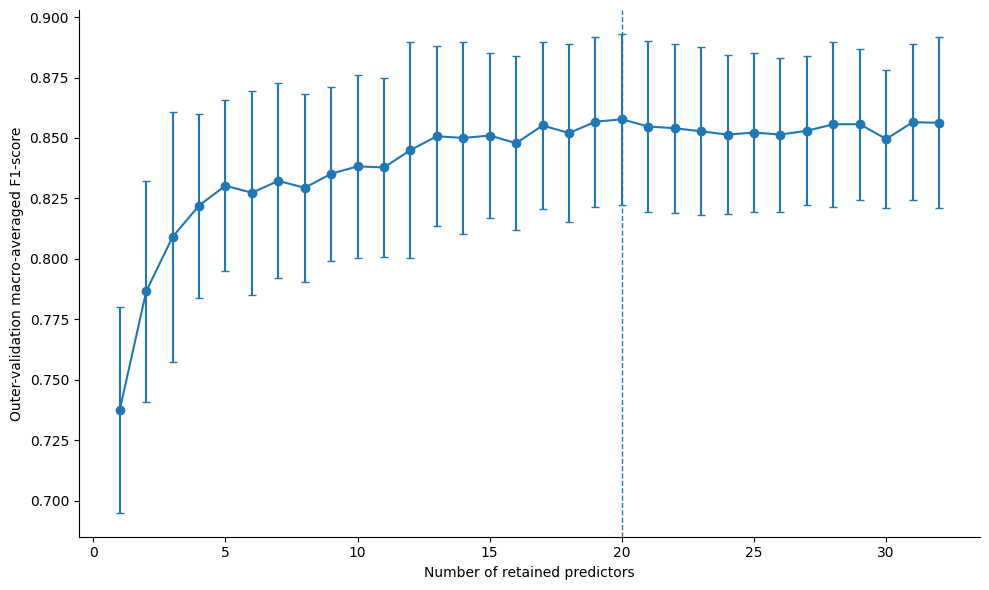

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    feature_count_summary[
        "Number_of_Selected_Predictors"
    ],
    feature_count_summary[
        "CV_Macro_F1_Mean"
    ],
    yerr=feature_count_summary[
        "CV_Macro_F1_SD"
    ],
    marker="o",
    capsize=3,
)

ax.axvline(
    selected_k,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Number of retained predictors")
ax.set_ylabel("Outer-validation macro-averaged F1-score")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "predictor_count_macro_f1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    OUTPUT_DIR / "predictor_count_macro_f1.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

## 11. Obtain the final cross-validated ranking of all 32 predictors

In [12]:
final_ranking_cv = RepeatedStratifiedKFold(
    n_splits=FINAL_RANKING_SPLITS,
    n_repeats=FINAL_RANKING_REPEATS,
    random_state=SELECTION_SEED,
)

final_importance_records = []
final_fold_performance_records = []

for fold_number, (
    fold_train_index,
    fold_validation_index,
) in enumerate(
    final_ranking_cv.split(
        X_train,
        y_train,
    ),
    start=1,
):
    print(
        f"Final ranking fold {fold_number}/"
        f"{FINAL_RANKING_SPLITS * FINAL_RANKING_REPEATS}"
    )

    X_fold_train = X_train.iloc[
        fold_train_index
    ]

    X_fold_validation = X_train.iloc[
        fold_validation_index
    ]

    y_fold_train = y_train.iloc[
        fold_train_index
    ]

    y_fold_validation = y_train.iloc[
        fold_validation_index
    ]

    fold_pipeline = clone(
        tuned_lr_pipeline
    )

    fold_pipeline.fit(
        X_fold_train[ALL_PREDICTORS],
        y_fold_train,
    )

    fold_prediction = fold_pipeline.predict(
        X_fold_validation[ALL_PREDICTORS]
    )

    baseline_macro_f1 = f1_score(
        y_fold_validation,
        fold_prediction,
        average="macro",
        zero_division=0,
    )

    final_fold_performance_records.append({
        "Fold": fold_number,
        "Baseline_Macro_F1": baseline_macro_f1,
    })

    fold_permutation = permutation_importance(
        estimator=fold_pipeline,
        X=X_fold_validation[ALL_PREDICTORS],
        y=y_fold_validation,
        scoring=SCORING,
        n_repeats=FINAL_PERMUTATION_REPEATS,
        random_state=SELECTION_SEED + fold_number,
        n_jobs=-1,
    )

    for feature_index, feature_name in enumerate(
        ALL_PREDICTORS
    ):
        final_importance_records.append({
            "Fold": fold_number,
            "Feature": feature_name,
            "Fold_Mean_Importance": (
                fold_permutation.importances_mean[
                    feature_index
                ]
            ),
            "Fold_SD_Importance": (
                fold_permutation.importances_std[
                    feature_index
                ]
            ),
        })

final_importance_long = pd.DataFrame(
    final_importance_records
)

final_fold_performance = pd.DataFrame(
    final_fold_performance_records
)

final_feature_ranking = (
    final_importance_long
    .groupby("Feature", as_index=False)
    .agg(
        Permutation_Importance_Mean=(
            "Fold_Mean_Importance",
            "mean",
        ),
        Permutation_Importance_SD=(
            "Fold_Mean_Importance",
            "std",
        ),
        Positive_Fold_Rate=(
            "Fold_Mean_Importance",
            lambda values: float(
                np.mean(np.asarray(values) > 0)
            ),
        ),
        Number_of_Folds=(
            "Fold",
            "nunique",
        ),
    )
    .sort_values(
        [
            "Permutation_Importance_Mean",
            "Feature",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

final_feature_ranking.insert(
    0,
    "Overall_Rank",
    np.arange(
        1,
        len(final_feature_ranking) + 1,
    ),
)

display(final_feature_ranking.round(4))

Final ranking fold 1/25
Final ranking fold 2/25
Final ranking fold 3/25
Final ranking fold 4/25
Final ranking fold 5/25
Final ranking fold 6/25
Final ranking fold 7/25
Final ranking fold 8/25
Final ranking fold 9/25
Final ranking fold 10/25
Final ranking fold 11/25
Final ranking fold 12/25
Final ranking fold 13/25
Final ranking fold 14/25
Final ranking fold 15/25
Final ranking fold 16/25
Final ranking fold 17/25
Final ranking fold 18/25
Final ranking fold 19/25
Final ranking fold 20/25
Final ranking fold 21/25
Final ranking fold 22/25
Final ranking fold 23/25
Final ranking fold 24/25
Final ranking fold 25/25


,Overall_Rank,Feature,Permutation_Importance_Mean,Permutation_Importance_SD,Positive_Fold_Rate,Number_of_Folds
0,1,SN4,0.0299,0.0228,0.96,25
1,2,PBC3,0.0293,0.0170,0.96,25
2,3,PBC4,0.0279,0.0213,0.84,25
3,4,ATTD4,0.0180,0.0144,0.96,25
4,5,PBC1,0.0171,0.0146,0.88,25
5,6,PBC2,0.0109,0.0172,0.72,25
6,7,A2,0.0084,0.0153,0.60,25
7,8,ATTD3,0.0078,0.0174,0.64,25
8,9,SN1,0.0049,0.0116,0.60,25
9,10,A3,0.0043,0.0112,0.56,25


## 12. Select and display the top predictors

In [13]:
def identify_feature_group(feature):
    if feature in ATTD_COLUMNS:
        return "Attitude"
    if feature in PBC_COLUMNS:
        return "Perceived behavioural control"
    if feature in SN_COLUMNS:
        return "Subjective norm"
    if feature in VIDEO_COLUMNS:
        return "Video content"
    raise ValueError(f"Unknown feature: {feature}")


final_feature_ranking[
    "Feature_Group"
] = (
    final_feature_ranking["Feature"]
    .map(identify_feature_group)
)

selected_feature_table = (
    final_feature_ranking
    .head(selected_k)
    .copy()
)

selected_features = (
    selected_feature_table["Feature"]
    .tolist()
)

selected_tpb_features = [
    feature
    for feature in selected_features
    if feature in TPB_COLUMNS
]

selected_video_features = [
    feature
    for feature in selected_features
    if feature in VIDEO_COLUMNS
]

VIDEO_DIMENSION_MAP = {
    "V1": "Visual presentation",
    "V2": "Visual presentation",
    "V3": "Visual presentation",
    "E1": "Editing",
    "E2": "Editing",
    "E3": "Editing",
    "H1": "Opening hook",
    "H2": "Opening hook",
    "A1": "Audio and music",
    "A2": "Audio and music",
    "A3": "Audio and music",
    "T1": "On-screen text",
    "T2": "On-screen text",
    "T3": "On-screen text",
    "P1": "Product presentation",
    "P2": "Product presentation",
    "P3": "Product presentation",
    "EM1": "Emotional appeal",
    "EM2": "Emotional appeal",
    "EM3": "Emotional appeal",
}

selected_video_table = (
    selected_feature_table
    .loc[
        selected_feature_table[
            "Feature"
        ].isin(VIDEO_COLUMNS)
    ]
    .copy()
)

selected_video_table[
    "Video_Dimension"
] = (
    selected_video_table["Feature"]
    .map(VIDEO_DIMENSION_MAP)
)

print("Selected total predictors:", len(selected_features))
print("Selected TPB predictors:", len(selected_tpb_features))
print(selected_tpb_features)
print("Selected video predictors:", len(selected_video_features))
print(selected_video_features)

display(selected_feature_table.round(4))
display(selected_video_table.round(4))

Selected total predictors: 20
Selected TPB predictors: 12
['SN4', 'PBC3', 'PBC4', 'ATTD4', 'PBC1', 'PBC2', 'ATTD3', 'SN1', 'ATTD1', 'SN2', 'SN3', 'ATTD2']
Selected video predictors: 8
['A2', 'A3', 'T3', 'V1', 'V3', 'EM1', 'EM3', 'H1']


,Overall_Rank,Feature,Permutation_Importance_Mean,Permutation_Importance_SD,Positive_Fold_Rate,Number_of_Folds,Feature_Group
0,1,SN4,0.0299,0.0228,0.96,25,Subjective norm
1,2,PBC3,0.0293,0.0170,0.96,25,Perceived behavioural control
2,3,PBC4,0.0279,0.0213,0.84,25,Perceived behavioural control
3,4,ATTD4,0.0180,0.0144,0.96,25,Attitude
4,5,PBC1,0.0171,0.0146,0.88,25,Perceived behavioural control
5,6,PBC2,0.0109,0.0172,0.72,25,Perceived behavioural control
6,7,A2,0.0084,0.0153,0.60,25,Video content
7,8,ATTD3,0.0078,0.0174,0.64,25,Attitude
8,9,SN1,0.0049,0.0116,0.60,25,Subjective norm
9,10,A3,0.0043,0.0112,0.56,25,Video content


,Overall_Rank,Feature,Permutation_Importance_Mean,Permutation_Importance_SD,Positive_Fold_Rate,Number_of_Folds,Feature_Group,Video_Dimension
6,7,A2,0.0084,0.0153,0.60,25,Video content,Audio and music
9,10,A3,0.0043,0.0112,0.56,25,Video content,Audio and music
14,15,T3,0.0031,0.0106,0.44,25,Video content,On-screen text
15,16,V1,0.0022,0.0078,0.48,25,Video content,Visual presentation
16,17,V3,0.0019,0.0080,0.40,25,Video content,Visual presentation
17,18,EM1,0.0019,0.0128,0.56,25,Video content,Emotional appeal
18,19,EM3,0.0019,0.0106,0.56,25,Video content,Emotional appeal
19,20,H1,0.0016,0.0059,0.40,25,Video content,Opening hook


In [14]:
VIDEO_DIMENSION_MAP = {
    "V1": "Visual presentation",
    "V2": "Visual presentation",
    "V3": "Visual presentation",

    "E1": "Editing",
    "E2": "Editing",
    "E3": "Editing",

    "H1": "Opening hook",
    "H2": "Opening hook",

    "A1": "Audio and music",
    "A2": "Audio and music",
    "A3": "Audio and music",

    "T1": "On-screen text",
    "T2": "On-screen text",
    "T3": "On-screen text",

    "P1": "Product presentation",
    "P2": "Product presentation",
    "P3": "Product presentation",

    "EM1": "Emotional appeal",
    "EM2": "Emotional appeal",
    "EM3": "Emotional appeal",
}

selected_video_table = (
    selected_feature_table
    .loc[
        selected_feature_table[
            "Feature"
        ].isin(VIDEO_COLUMNS)
    ]
    .copy()
)

selected_video_table[
    "Video_Dimension"
] = (
    selected_video_table[
        "Feature"
    ].map(
        VIDEO_DIMENSION_MAP
    )
)

selected_video_table = (
    selected_video_table[
        [
            "Feature",
            "Video_Dimension",
            "Permutation_Importance_Mean",
            "Permutation_Importance_SD",
            "Positive_Fold_Rate",
        ]
    ]
)

display(
    selected_video_table.round(4)
)

,Feature,Video_Dimension,Permutation_Importance_Mean,Permutation_Importance_SD,Positive_Fold_Rate
6,A2,Audio and music,0.0084,0.0153,0.60
9,A3,Audio and music,0.0043,0.0112,0.56
14,T3,On-screen text,0.0031,0.0106,0.44
15,V1,Visual presentation,0.0022,0.0078,0.48
16,V3,Visual presentation,0.0019,0.0080,0.40
17,EM1,Emotional appeal,0.0019,0.0128,0.56
18,EM3,Emotional appeal,0.0019,0.0106,0.56
19,H1,Opening hook,0.0016,0.0059,0.40


## 13. Publication-ready bar graph of the selected predictors

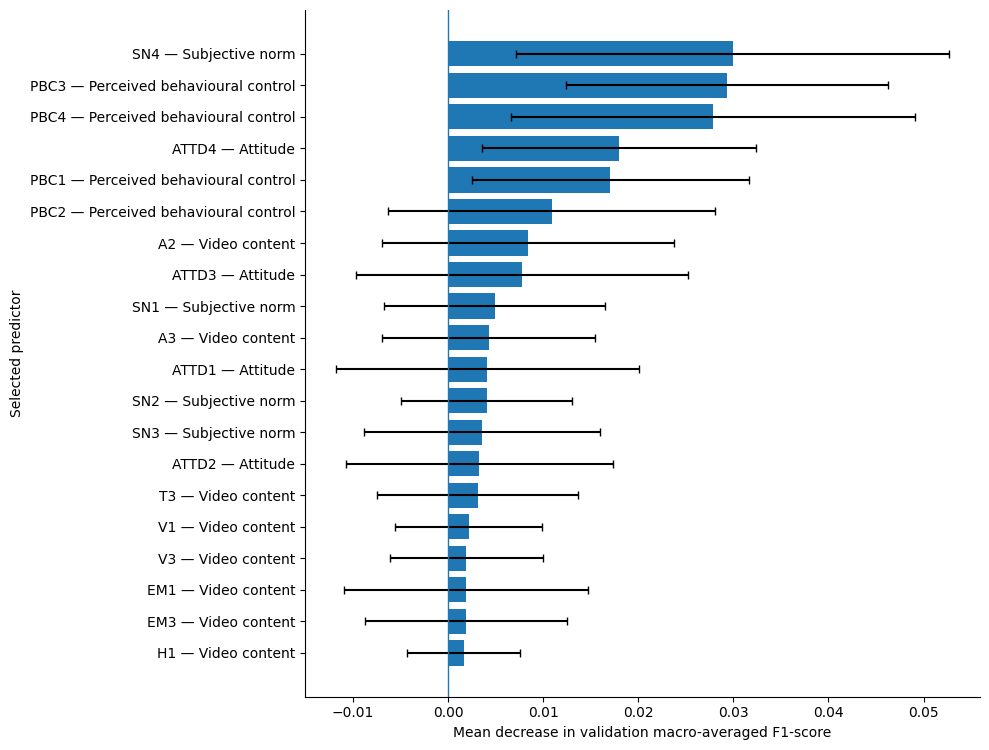

In [15]:
plot_data = (
    selected_feature_table
    .sort_values(
        "Permutation_Importance_Mean",
        ascending=True,
    )
    .copy()
)

plot_data["Feature_Label"] = (
    plot_data["Feature"]
    + " — "
    + plot_data["Feature_Group"]
)

fig, ax = plt.subplots(
    figsize=(
        10,
        max(
            6,
            0.38 * len(plot_data),
        ),
    )
)

ax.barh(
    plot_data["Feature_Label"],
    plot_data["Permutation_Importance_Mean"],
    xerr=plot_data["Permutation_Importance_SD"],
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Mean decrease in validation macro-averaged F1-score"
)
ax.set_ylabel("Selected predictor")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "selected_predictor_permutation_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    OUTPUT_DIR
    / "selected_predictor_permutation_importance.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

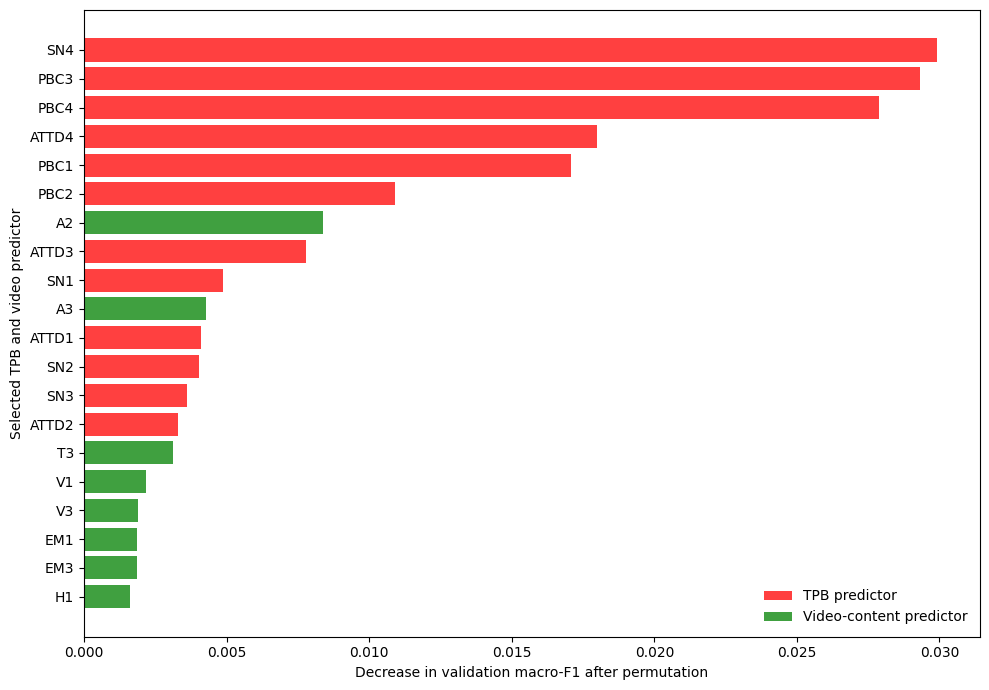

In [16]:
from matplotlib.patches import Patch

plot_data = (
    selected_feature_table
    .sort_values(
        "Permutation_Importance_Mean",
        ascending=True,
    )
    .copy()
)

plot_data["Bar_Color"] = np.where(
    plot_data["Feature"].isin(VIDEO_COLUMNS),
    "green",
    "red",
)

plt.figure(
    figsize=(
        10,
        max(
            6,
            0.35 * len(plot_data),
        ),
    )
)

plt.barh(
    plot_data["Feature"],
    plot_data["Permutation_Importance_Mean"],
    color=plot_data["Bar_Color"],
    alpha=0.75,
)

plt.xlabel(
    "Decrease in validation macro-F1 after permutation"
)

plt.ylabel(
    "Selected TPB and video predictor"
)

# plt.title(
#     "Selected Predictors from Cross-Validated "
#     "Permutation Importance"
# )

legend_items = [
    Patch(
        facecolor="red",
        alpha=0.75,
        label="TPB predictor",
    ),
    Patch(
        facecolor="green",
        alpha=0.75,
        label="Video-content predictor",
    ),
]

plt.legend(
    handles=legend_items,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "selected_all_feature_importance_red_green.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 14. Fit and evaluate the final selected-predictor model

In [17]:
# Clone the exact tuned LR pipeline; no LR is redefined here.
final_selected_pipeline = clone(
    tuned_lr_pipeline
)

final_selected_pipeline.fit(
    X_train[selected_features],
    y_train,
)

test_prediction = final_selected_pipeline.predict(
    X_test[selected_features]
)

final_test_metrics = pd.DataFrame([{
    "Number_of_Predictors": len(selected_features),
    "Accuracy": accuracy_score(
        y_test,
        test_prediction,
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        test_prediction,
    ),
    "Macro_Precision": precision_score(
        y_test,
        test_prediction,
        average="macro",
        zero_division=0,
    ),
    "Macro_Recall": recall_score(
        y_test,
        test_prediction,
        average="macro",
        zero_division=0,
    ),
    "Macro_F1": f1_score(
        y_test,
        test_prediction,
        average="macro",
        zero_division=0,
    ),
}])

test_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        test_prediction,
        output_dict=True,
        zero_division=0,
    )
).T

display(final_test_metrics.round(4))
display(test_classification_report.round(4))

,Number_of_Predictors,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,20,0.8415,0.8773,0.808,0.8773,0.8222


,precision,recall,f1-score,support
HIGH,0.9796,0.8000,0.8807,60.0000
LOW,0.6364,0.9545,0.7636,22.0000
accuracy,0.8415,0.8415,0.8415,0.8415
macro avg,0.8080,0.8773,0.8222,82.0000
weighted avg,0.8875,0.8415,0.8493,82.0000


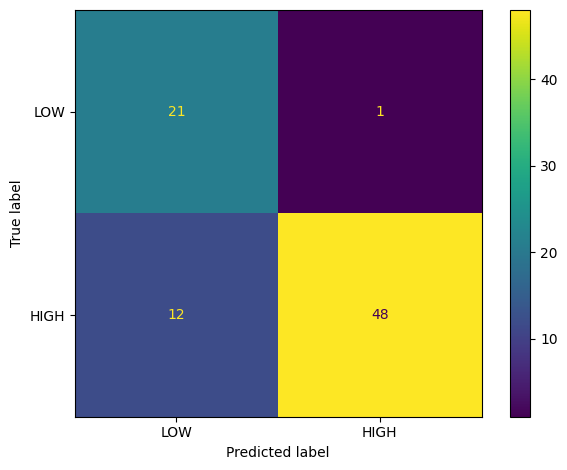

In [18]:
labels = ["LOW", "HIGH"]

cm = confusion_matrix(
    y_test,
    test_prediction,
    labels=labels,
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

display_cm.plot()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "selected_predictor_lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 15. Compare the selected-predictor and full 32-predictor LR models

In [19]:
full_pipeline = clone(
    tuned_lr_pipeline
)

full_pipeline.fit(
    X_train[ALL_PREDICTORS],
    y_train,
)

full_test_prediction = full_pipeline.predict(
    X_test[ALL_PREDICTORS]
)

test_model_comparison = pd.DataFrame([
    {
        "Model": "Selected-predictor LR",
        "Number_of_Predictors": len(selected_features),
        "Test_Macro_F1": f1_score(
            y_test,
            test_prediction,
            average="macro",
            zero_division=0,
        ),
        "Test_Balanced_Accuracy": balanced_accuracy_score(
            y_test,
            test_prediction,
        ),
        "Test_Accuracy": accuracy_score(
            y_test,
            test_prediction,
        ),
    },
    {
        "Model": "Full 32-predictor LR",
        "Number_of_Predictors": len(ALL_PREDICTORS),
        "Test_Macro_F1": f1_score(
            y_test,
            full_test_prediction,
            average="macro",
            zero_division=0,
        ),
        "Test_Balanced_Accuracy": balanced_accuracy_score(
            y_test,
            full_test_prediction,
        ),
        "Test_Accuracy": accuracy_score(
            y_test,
            full_test_prediction,
        ),
    },
])

display(test_model_comparison.round(4))

,Model,Number_of_Predictors,Test_Macro_F1,Test_Balanced_Accuracy,Test_Accuracy
0,Selected-predictor LR,20,0.8222,0.8773,0.8415
1,Full 32-predictor LR,32,0.8222,0.8773,0.8415


## 16. Export tables, figures, settings, and fitted pipelines

In [20]:
def make_json_safe(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    return value


excel_path = (
    OUTPUT_DIR
    / "Combined_HyperTune_and_FeatureSelection_results.xlsx"
)

with pd.ExcelWriter(excel_path) as writer:
    class_distribution.to_excel(
        writer,
        sheet_name="Class_Distribution",
        index=False,
    )
    split_summary.to_excel(
        writer,
        sheet_name="Data_Split",
        index=False,
    )
    parameter_grid_summary.to_excel(
        writer,
        sheet_name="Grid_Summary",
        index=False,
    )
    hyperparameter_results.to_excel(
        writer,
        sheet_name="Hyperparameter_Results",
        index=False,
    )
    tuned_lr_audit.to_excel(
        writer,
        sheet_name="Tuned_LR_Audit",
        index=False,
    )
    feature_count_results.to_excel(
        writer,
        sheet_name="Outer_Fold_Results",
        index=False,
    )
    feature_count_summary.to_excel(
        writer,
        sheet_name="Feature_Count_Summary",
        index=False,
    )
    selection_summary.to_excel(
        writer,
        sheet_name="Selected_Count",
        index=False,
    )
    outer_rankings.to_excel(
        writer,
        sheet_name="Outer_Fold_Rankings",
        index=False,
    )
    final_fold_performance.to_excel(
        writer,
        sheet_name="Final_Ranking_Performance",
        index=False,
    )
    final_importance_long.to_excel(
        writer,
        sheet_name="Final_Importance_Raw",
        index=False,
    )
    final_feature_ranking.to_excel(
        writer,
        sheet_name="All_32_Feature_Ranking",
        index=False,
    )
    selected_feature_table.to_excel(
        writer,
        sheet_name="Selected_Top_Features",
        index=False,
    )
    selected_video_table.to_excel(
        writer,
        sheet_name="Selected_Video_Features",
        index=False,
    )
    final_test_metrics.to_excel(
        writer,
        sheet_name="Selected_Test_Metrics",
        index=False,
    )
    test_classification_report.to_excel(
        writer,
        sheet_name="Selected_Class_Report",
    )
    test_model_comparison.to_excel(
        writer,
        sheet_name="Test_Model_Comparison",
        index=False,
    )

selected_model_path = (
    OUTPUT_DIR
    / "final_selected_predictor_lr_pipeline.joblib"
)

full_model_path = (
    OUTPUT_DIR
    / "full_32_predictor_lr_pipeline.joblib"
)

joblib.dump(
    final_selected_pipeline,
    selected_model_path,
)

joblib.dump(
    full_pipeline,
    full_model_path,
)

settings_path = (
    OUTPUT_DIR
    / "combined_analysis_settings.json"
)

settings = {
    "data_path": str(data_path),
    "split_seed": SPLIT_SEED,
    "cv_seed": CV_SEED,
    "smote_seed": SMOTE_SEED,
    "selection_seed": SELECTION_SEED,
    "test_size": TEST_SIZE,
    "selected_model": "Logistic Regression",
    "tuned_parameter_grid_result": {
        key.replace("model__", ""): make_json_safe(value)
        for key, value in lr_search.best_params_.items()
    },
    "fixed_logistic_regression_settings": {
        "max_iter": tuned_lr_model.max_iter,
        "random_state": tuned_lr_model.random_state,
    },
    "selected_number_of_predictors": selected_k,
    "selected_features": selected_features,
    "selected_tpb_features": selected_tpb_features,
    "selected_video_features": selected_video_features,
    "selection_metric": (
        "Highest mean outer-validation macro-F1"
    ),
}

with settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        settings,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Excel results:", excel_path)
print("Selected-predictor model:", selected_model_path)
print("Full model:", full_model_path)
print("Settings:", settings_path)

Excel results: combined_phase2_phase3_outputs\Combined_HyperTune_and_FeatureSelection_results.xlsx
Selected-predictor model: combined_phase2_phase3_outputs\final_selected_predictor_lr_pipeline.joblib
Full model: combined_phase2_phase3_outputs\full_32_predictor_lr_pipeline.joblib
Settings: combined_phase2_phase3_outputs\combined_analysis_settings.json
